# Part 2: ResNet-18 Model Improvement Ablations

This notebook keeps the Part 2 workflow notebook-owned while moving reusable training and result logic into project modules. The regular-training baseline is loaded from Part 1 results; the remaining ablations are trained here.

In [1]:
from pathlib import Path
import importlib
import os
import sys

In [2]:
current = Path.cwd().resolve()
for candidate in [current, *current.parents]:
    if (candidate / 'src').is_dir() and (candidate / 'requirements.txt').exists():
        ROOT = candidate
        break
else:
    ROOT = current

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
os.chdir(ROOT)

In [3]:
def install_project_requirements_for_colab(project_root: Path) -> None:
    """Install non-PyTorch dependencies in Colab without replacing CUDA-matched torch wheels."""
    try:
        import google.colab  # type: ignore  # noqa: F401
    except ImportError:
        return

    import subprocess

    requirements_path = project_root / 'requirements.txt'
    filtered_requirements = Path('/tmp/mlds_colab_requirements.txt')
    skip_prefixes = ('torch', 'torchvision')
    filtered_lines = [
        line
        for line in requirements_path.read_text().splitlines()
        if not line.strip().lower().startswith(skip_prefixes)
    ]
    filtered_requirements.write_text('\n'.join(filtered_lines) + '\n')
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-r', str(filtered_requirements)])


In [4]:
install_project_requirements_for_colab(ROOT)

ROOT

PosixPath('/Users/royrubin/Documents/GitHub/MLDS_Final_Project')

In [5]:
import pandas as pd
from IPython.core.display import Image
from IPython.display import display

import src.evaluation.experiment_results as experiment_results

experiment_results = importlib.reload(experiment_results)
import src.experiments.part2 as part2_experiments  # noqa: E402
part2_experiments = importlib.reload(part2_experiments)
experiment_output_paths = experiment_results.experiment_output_paths
get_device = experiment_results.get_device
load_part1_model_baseline_aggregated = experiment_results.load_part1_model_baseline_aggregated
run_part2_improvement_experiments = part2_experiments.run_part2_improvement_experiments
from src.utils.config import Part2ExperimentConfig  # noqa: E402
from src.utils.reproducibility import seed_everything  # noqa: E402

/Users/royrubin/opt/anaconda3/envs/mlds_dogs_vs_cats/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Configuration

In [6]:
config = Part2ExperimentConfig()
device = get_device(config)
output_paths = experiment_output_paths(config.results_dir, config.figures_dir, config.part)
seed_everything(config.seed, deterministic=config.deterministic)

pd.DataFrame(
    [
        {
            'part': config.part,
            'config_name': config.config_name,
            'model_name': config.model_name,
            'tiles_per_side_values': config.tiles_per_side_values,
            'num_tile_permutations': config.num_tile_permutations,
            'epochs': config.epochs,
            'device': str(device),
        }
    ]
)

Selected device: cpu


,part,config_name,model_name,tiles_per_side_values,num_tile_permutations,epochs,device
0,part2,part2_improvement,resnet18,"[1, 3]",2,1,cpu


In [7]:
pd.DataFrame(config.ablations)

,name,use_pretrained,augmentation,curriculum
0,augmentation_combined_augmentations,True,combined_augmentations,NaN
1,augmentation_patch_shuffle,True,patch_shuffle,NaN
2,augmentation_random_erasing,True,random_erasing,NaN
3,augmentation_same_label_cutmix,True,same_label_cutmix,NaN
4,curriculum_corruption_probability,True,none,corruption_probability
5,curriculum_permutation_difficulty,True,none,permutation_difficulty


## Part 1 ResNet-18 Baseline

In [8]:
part1_baseline_aggregated = load_part1_model_baseline_aggregated(config, config.model_name)
if not part1_baseline_aggregated.empty:
    display(part1_baseline_aggregated)

,model_name,tiles_per_side,num_tiles,mean_final_epoch_val_accuracy,std_final_epoch_val_accuracy,mean_best_epoch_val_accuracy,std_best_epoch_val_accuracy,n_runs,ablation_name,config_name
0,resnet18,3.0,9,0.836538,0.067991,0.836538,0.067991,2,regular_part1,part2_improvement
1,resnet18,NaN,1,0.865385,NaN,0.865385,NaN,1,regular_part1,part2_improvement


## Train Improvement Ablations

In [9]:
RUN_TRAINING = True

if RUN_TRAINING:
    part2_results = run_part2_improvement_experiments(config=config, device=device)
    display(part2_results)
else:
    print('Training is skipped. Set RUN_TRAINING = True to train Part 2 ablations in this notebook.')

Raw results path: /Users/royrubin/Documents/GitHub/MLDS_Final_Project/outputs/results/part2_raw_results.csv
Checkpointing disabled outside Google Colab.
Saved 18 pending row(s) for model 'resnet18'.

Running ablation: augmentation_combined_augmentations

[1/3]
model=resnet18, ablation=augmentation_combined_augmentations, tiles_per_side=None, tile_permutation_id=0, seed=42
stages=1
[1. standard: 1 epoch]
Building dataloaders...
Built dataloaders: 
	train=204 samples in 13 batches
	validation=52 samples in 4 batches.
Building model 'resnet18'...


resnet18 [augmentation_combined_augmentations] 1x1 permutation #0. epochs progress: 100%|██████████| 1/1 [01:08<00:00, 68.14s/epoch, best_val_accuracy=0.846, stage=standard, train_accuracy=0.76, train_loss=0.454, val_accuracy=0.846, val_loss=0.407]


Current run runtime: 1m 09s
Total training runtime: 1m 09s

[2/3]
model=resnet18, ablation=augmentation_combined_augmentations, tiles_per_side=3, tile_permutation_id=1, seed=42
stages=1
[1. standard: 1 epoch]
Building dataloaders...
Built dataloaders: 
	train=204 samples in 13 batches
	validation=52 samples in 4 batches.
Building model 'resnet18'...


resnet18 [augmentation_combined_augmentations] 3x3 permutation #1. epochs progress: 100%|██████████| 1/1 [01:03<00:00, 63.35s/epoch, best_val_accuracy=0.827, stage=standard, train_accuracy=0.789, train_loss=0.438, val_accuracy=0.827, val_loss=0.74]


Current run runtime: 1m 04s
Total training runtime: 2m 33s

[3/3]
model=resnet18, ablation=augmentation_combined_augmentations, tiles_per_side=3, tile_permutation_id=2, seed=42
stages=1
[1. standard: 1 epoch]
Building dataloaders...
Built dataloaders: 
	train=204 samples in 13 batches
	validation=52 samples in 4 batches.
Building model 'resnet18'...


...

resnet18 [curriculum_permutation_difficulty] 3x3 permutation #1. epochs progress: 100%|██████████| 3/3 [05:35<00:00, 111.69s/epoch, best_val_accuracy=0.942, stage=3x3_permutation, train_accuracy=0.931, train_loss=0.157, val_accuracy=0.942, val_loss=0.189]


Current run runtime: 5m 36s
Total training runtime: 37m 38s

[3/3]
model=resnet18, ablation=curriculum_permutation_difficulty, tiles_per_side=3, tile_permutation_id=2, seed=42
stages=3
[1. original: 1 epoch
2. 2x2_permutation: 1 epoch
3. 3x3_permutation: 1 epoch]
Building dataloaders...
Built dataloaders: 
	train=204 samples in 13 batches
	validation=52 samples in 4 batches.
Stage dataloaders: original=204 samples / 13 batches; 2x2_permutation=204 samples / 13 batches; 3x3_permutation=204 samples / 13 batches.
Building model 'resnet18'...


resnet18 [curriculum_permutation_difficulty] 3x3 permutation #2. epochs progress: 100%|██████████| 3/3 [03:55<00:00, 78.60s/epoch, best_val_accuracy=0.923, stage=3x3_permutation, train_accuracy=0.931, train_loss=0.255, val_accuracy=0.846, val_loss=0.465] 


Current run runtime: 3m 57s
Total training runtime: 42m 34s


,model_name,ablation_name,tiles_per_side,num_tiles,mean_final_epoch_val_accuracy,std_final_epoch_val_accuracy,mean_best_epoch_val_accuracy,std_best_epoch_val_accuracy,n_runs
0,resnet18,augmentation_combined_augmentations,3.0,9,0.817308,0.013598,0.817308,0.013598,2
1,resnet18,augmentation_combined_augmentations,NaN,1,0.846154,NaN,0.846154,NaN,1
2,resnet18,augmentation_patch_shuffle,3.0,9,0.875000,0.013598,0.875000,0.013598,2
3,resnet18,augmentation_patch_shuffle,NaN,1,0.961538,NaN,0.961538,NaN,1
4,resnet18,augmentation_random_erasing,3.0,9,0.836538,0.095187,0.836538,0.095187,2
5,resnet18,augmentation_random_erasing,NaN,1,0.961538,NaN,0.961538,NaN,1
6,resnet18,augmentation_same_label_cutmix,3.0,9,0.846154,0.135982,0.846154,0.135982,2
7,resnet18,augmentation_same_label_cutmix,NaN,1,0.942308,NaN,0.942308,NaN,1
8,resnet18,curriculum_corruption_probability,3.0,9,0.788462,0.163178,0.971154,0.013598,2
9,resnet18,curriculum_corruption_probability,NaN,1,0.961538,NaN,0.961538,NaN,1


## Results

In [10]:
results_path = Path(output_paths['aggregated_results'])

if results_path.exists():
    part2_results = pd.read_csv(results_path)
    if 'regular_part1' not in set(part2_results.get('ablation_name', [])) and not part1_baseline_aggregated.empty:
        part2_results = pd.concat([part1_baseline_aggregated, part2_results], ignore_index=True, sort=False)
    display(part2_results.sort_values(['tiles_per_side', 'ablation_name']))
else:
    print('Part 2 aggregated results were not found. Set RUN_TRAINING = True and run the training cell.')
    if part1_baseline_aggregated.empty:
        print('Part 1 ResNet-18 baseline results were also not found; run Part 1 first to include regular_part1.')

,model_name,ablation_name,tiles_per_side,num_tiles,mean_final_epoch_val_accuracy,std_final_epoch_val_accuracy,mean_best_epoch_val_accuracy,std_best_epoch_val_accuracy,n_runs
0,resnet18,augmentation_combined_augmentations,3.0,9,0.817308,0.013598,0.817308,0.013598,2
2,resnet18,augmentation_patch_shuffle,3.0,9,0.875000,0.013598,0.875000,0.013598,2
4,resnet18,augmentation_random_erasing,3.0,9,0.836538,0.095187,0.836538,0.095187,2
6,resnet18,augmentation_same_label_cutmix,3.0,9,0.846154,0.135982,0.846154,0.135982,2
8,resnet18,curriculum_corruption_probability,3.0,9,0.788462,0.163178,0.971154,0.013598,2
10,resnet18,curriculum_permutation_difficulty,3.0,9,0.894231,0.067991,0.932692,0.013598,2
12,resnet18,regular_part1,3.0,9,0.836538,0.067991,0.836538,0.067991,2
1,resnet18,augmentation_combined_augmentations,NaN,1,0.846154,NaN,0.846154,NaN,1
3,resnet18,augmentation_patch_shuffle,NaN,1,0.961538,NaN,0.961538,NaN,1
5,resnet18,augmentation_random_erasing,NaN,1,0.961538,NaN,0.961538,NaN,1


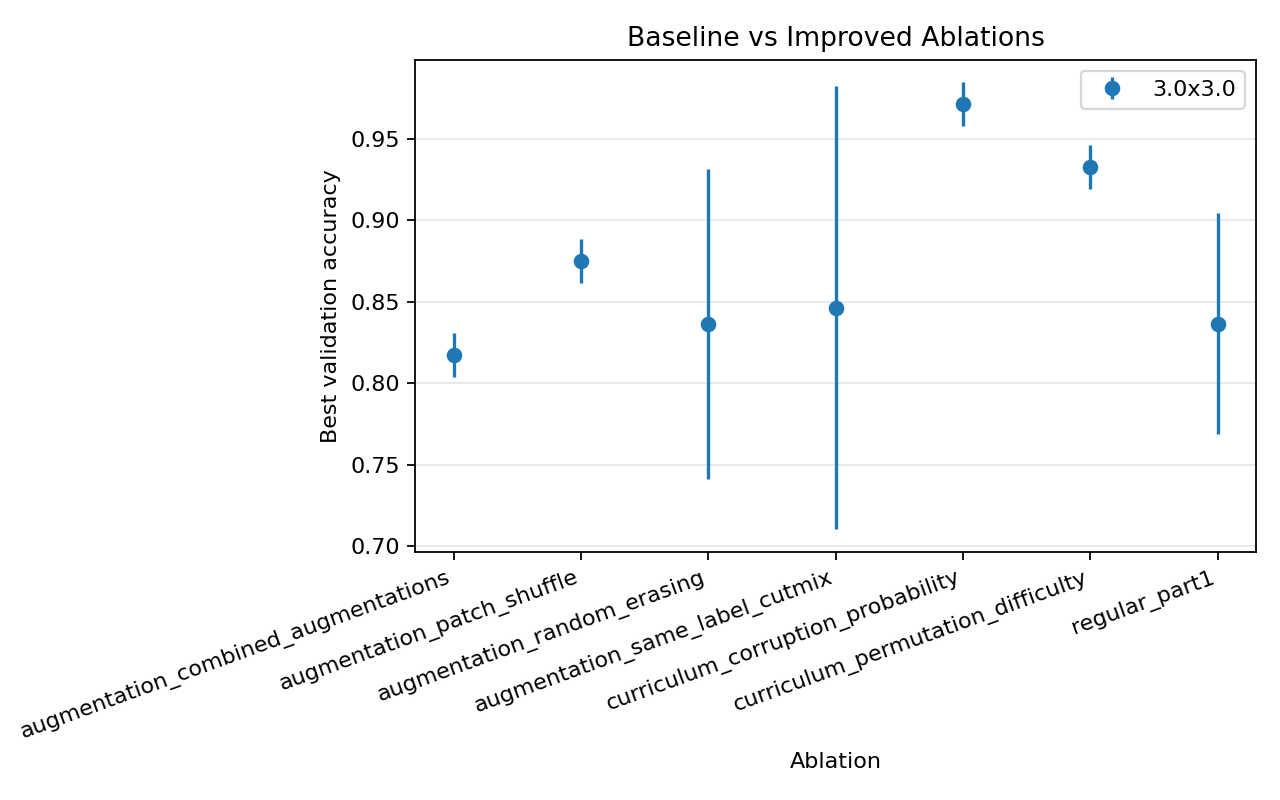

In [11]:
figure_path = Path(output_paths['figure'])
if figure_path.exists():
    display(Image(filename=str(figure_path)))
else:
    print('Part 2 ablation figure has not been generated yet.')